# Titanic Dataset - TensorFlow/Keras Neural Network Classification

This notebook implements deep learning models using TensorFlow/Keras for Titanic survival classification with activation function comparisons.

## Objectives:
1. Load preprocessed data
2. Build two neural network architectures with Keras:
   - **Basic feedforward network** (minimum 2 hidden layers)
   - **Advanced network** with Dropout, Batch Normalization, and L2 regularization
3. **Compare activation functions**: ReLU, LeakyReLU, GELU
4. Train models for 10-20 epochs with fixed hyperparameters
5. Evaluate model performance with appropriate metrics for class imbalance
6. Visualize training progress and loss/metric graphs
7. Save trained models

In [18]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle

# TensorFlow/Keras imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization, Input, Add, Activation
)

# Scikit-learn imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Check TensorFlow version and GPU availability
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")
if len(tf.config.list_physical_devices('GPU')) > 0:
    print(f"GPU devices: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.16.1
GPU available: False


## 1. Load and Prepare Data

In [19]:
# Load preprocessed data
data_path = Path('../data/processed/titanic_processed.csv')
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (891, 29)

Columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'FarePerPerson', 'HasCabin', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'AgeGroup_Teenager', 'AgeGroup_Young Adult', 'AgeGroup_Adult', 'AgeGroup_Senior', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Deck_Unknown']

First few rows:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,FarePerPerson,...,AgeGroup_Adult,AgeGroup_Senior,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_Unknown
0,0,3,0,22.0,1,0,7.2500,2,0,3.62500,...,0,0,0,0,0,0,0,0,0,1
1,1,1,1,38.0,1,0,71.2833,2,0,35.64165,...,1,0,0,1,0,0,0,0,0,0
2,1,3,1,26.0,0,0,7.9250,1,1,7.92500,...,0,0,0,0,0,0,0,0,0,1
3,1,1,1,35.0,1,0,53.1000,2,0,26.55000,...,0,0,0,1,0,0,0,0,0,0
4,0,3,0,35.0,0,0,8.0500,1,1,8.05000,...,0,0,0,0,0,0,0,0,0,1


In [20]:
# Separate features and target
X = df.drop('Survived', axis=1).values
y = df['Survived'].values

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"\nClass distribution:")
unique, counts = np.unique(y, return_counts=True)
for label, count in zip(unique, counts):
    print(f"Class {label}: {count} ({count/len(y)*100:.2f}%)")

Features shape: (891, 28)
Target shape: (891,)
Number of features: 28

Class distribution:
Class 0: 549 (61.62%)
Class 1: 342 (38.38%)


In [21]:
# Split data into train, validation, and test sets
# First split: 80% train+val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Second split: 75% train, 25% validation (of the 80%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"Training set size: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set size: {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTraining set survival rate: {y_train.mean():.2%}")
print(f"Validation set survival rate: {y_val.mean():.2%}")
print(f"Test set survival rate: {y_test.mean():.2%}")

Training set size: 534 (59.9%)
Validation set size: 178 (20.0%)
Test set size: 179 (20.1%)

Training set survival rate: 38.39%
Validation set survival rate: 38.20%
Test set survival rate: 38.55%


In [22]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")
print(f"\nScaled features statistics (training set):")
print(f"Mean: {X_train_scaled.mean(axis=0)[:5]}...")  # Show first 5
print(f"Std: {X_train_scaled.std(axis=0)[:5]}...")  # Show first 5

Feature scaling completed.

Scaled features statistics (training set):
Mean: [ 1.62375315e-16  7.11041712e-17  7.59639958e-17  1.14348813e-17
 -2.61962736e-17]...
Std: [1. 1. 1. 1. 1.]...


## 2. Define Evaluation Functions

In [23]:
def evaluate_model(model, X_test, y_test, model_name):
    """Evaluate a Keras model and return metrics."""
    # Make predictions
    y_pred_proba = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_pred_proba > 0.5).astype(int)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    results = {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC AUC': roc_auc
    }
    
    return results, y_pred, y_pred_proba


def plot_training_history(history, model_name):
    """Plot training and validation metrics."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss plot
    axes[0].plot(history.history['loss'], label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'Training History - Loss ({model_name})')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy plot
    axes[1].plot(history.history['accuracy'], label='Train Accuracy')
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'Training History - Accuracy ({model_name})')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(y_true, y_pred, model_name):
    """Plot confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Did not survive', 'Survived'],
                yticklabels=['Did not survive', 'Survived'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()


def plot_roc_curve(y_true, y_pred_proba, model_name):
    """Plot ROC curve."""
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {model_name}')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("Evaluation functions defined.")

Evaluation functions defined.


## 3. Build Neural Network Models with Activation Function Support

### 3.1 Model Building Functions

In [24]:
def get_activation_layer(activation_name):
    """Return appropriate activation layer for Keras."""
    if activation_name == 'relu':
        return Activation('relu')
    elif activation_name == 'leaky_relu':
        return layers.LeakyReLU(alpha=0.01)
    elif activation_name == 'gelu':
        return Activation('gelu')
    else:
        raise ValueError(f"Unknown activation: {activation_name}")


def create_basic_nn(input_dim, hidden_size1=64, hidden_size2=32, 
                    activation='relu', learning_rate=0.001):
    """
    Create a basic feedforward neural network with 2 hidden layers.
    No regularization techniques.
    """
    model = Sequential([
        # Input layer
        Input(shape=(input_dim,)),
        
        # First hidden layer
        Dense(hidden_size1),
        get_activation_layer(activation),
        
        # Second hidden layer
        Dense(hidden_size2),
        get_activation_layer(activation),
        
        # Output layer
        Dense(1, activation='sigmoid')
    ])
    
    # Compile model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model


def create_advanced_nn(input_dim, hidden_size1=64, hidden_size2=32, 
                       dropout_rate=0.3, activation='relu', 
                       learning_rate=0.001, l2_reg=0.001):
    """
    Create an advanced neural network with Dropout, Batch Normalization, 
    and L2 regularization. Minimum 2 hidden layers.
    """
    model = Sequential([
        # Input layer
        Input(shape=(input_dim,)),
        
        # First hidden layer with regularization
        Dense(hidden_size1, kernel_regularizer=regularizers.l2(l2_reg)),
        BatchNormalization(),
        get_activation_layer(activation),
        Dropout(dropout_rate),
        
        # Second hidden layer with regularization
        Dense(hidden_size2, kernel_regularizer=regularizers.l2(l2_reg)),
        BatchNormalization(),
        get_activation_layer(activation),
        Dropout(dropout_rate),
        
        # Output layer
        Dense(1, activation='sigmoid')
    ])
    
    # Compile model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model


print("Model building functions defined:")
print("1. create_basic_nn() - Basic feedforward network (2 hidden layers)")
print("2. create_advanced_nn() - Advanced network with Dropout, BatchNorm, L2 regularization")
print("\nSupported activation functions: ReLU, LeakyReLU, GELU")

Model building functions defined:
1. create_basic_nn() - Basic feedforward network (2 hidden layers)
2. create_advanced_nn() - Advanced network with Dropout, BatchNorm, L2 regularization

Supported activation functions: ReLU, LeakyReLU, GELU


## 4. Activation Function Comparison Experiments

We will train both Basic and Advanced networks with different activation functions:
- **ReLU** (Rectified Linear Unit)
- **LeakyReLU** (Leaky ReLU with alpha = 0.01)
- **GELU** (Gaussian Error Linear Unit)

Each model will be trained for 15 epochs with fixed hyperparameters:
- Optimizer: Adam
- Learning Rate: 0.001
- L2 Regularization: 0.001 for Advanced models
- Dropout: 0.3 for Advanced models

### 4.1 Basic Neural Network - Activation Function Comparison

In [26]:
print("="*80)
print("BASIC NEURAL NETWORK - ACTIVATION FUNCTION COMPARISON")
print("="*80)

# Fixed hyperparameters
input_dim = X_train.shape[1]
NUM_EPOCHS = 15
LEARNING_RATE = 0.001
HIDDEN_SIZE1 = 64
HIDDEN_SIZE2 = 32

# Store results
basic_models = {}
basic_histories = {}
basic_results = {}

# Activation functions to compare
activations = ['relu', 'leaky_relu', 'gelu']

for activation in activations:
    print(f"\n{'='*80}")
    print(f"Training Basic NN with {activation.upper()} activation")
    print(f"{'='*80}")
    
    # Create model
    model = create_basic_nn(
        input_dim=input_dim,
        hidden_size1=HIDDEN_SIZE1,
        hidden_size2=HIDDEN_SIZE2,
        activation=activation,
        learning_rate=LEARNING_RATE
    )
    
    # Print model info
    print(f"\nModel Architecture:")
    model.summary()
    print(f"\nActivation function: {activation}")
    print(f"Training for {NUM_EPOCHS} epochs...")
    
    # Train model (no callbacks, fixed epochs)
    history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=NUM_EPOCHS,
        batch_size=32,
        verbose=1
    )
    
    # Store model and history
    basic_models[activation] = model
    basic_histories[activation] = history
    
    # Evaluate on test set
    results, y_pred, y_pred_proba = evaluate_model(
        model, X_test_scaled, y_test, f'Basic NN ({activation.upper()})'
    )
    basic_results[activation] = results
    
    print(f"\nTest Set Results for Basic NN ({activation.upper()}):")
    for key, value in results.items():
        if key != 'Model':
            print(f"{key}: {value:.4f}")

print(f"\n{'='*80}")
print("BASIC NN TRAINING COMPLETED FOR ALL ACTIVATIONS")
print(f"{'='*80}")

BASIC NEURAL NETWORK - ACTIVATION FUNCTION COMPARISON

Training Basic NN with RELU activation

Model Architecture:


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 64)             │         1,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,969 (15.50 KB)

 Trainable params: 3,969 (15.50 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 64)             │         1,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,969 (15.50 KB)

 Trainable params: 3,969 (15.50 KB)

 Non-trainable params: 0 (0.00 B)


Activation function: gelu
Training for 15 epochs...
Epoch 1/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4622 - loss: 0.7068 - val_accuracy: 0.7584 - val_loss: 0.5737
Epoch 2/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7835 - loss: 0.5281 - val_accuracy: 0.8034 - val_loss: 0.4948
Epoch 3/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8260 - loss: 0.4498 - val_accuracy: 0.8258 - val_loss: 0.4623
Epoch 4/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8312 - loss: 0.4173 - val_accuracy: 0.8146 - val_loss: 0.4557
Epoch 5/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8350 - loss: 0.4023 - val_accuracy: 0.8258 - val_loss: 0.4543
Epoch 6/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8394 - loss: 0.3917 - val_accuracy: 0.8146 - val_loss: 0.4538
Epoch 7/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8473 - loss: 0.3832 - val_accuracy: 0.8146 - val_loss: 0.4549
Epoch 8/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8

Basic NN - Training Curves Comparison


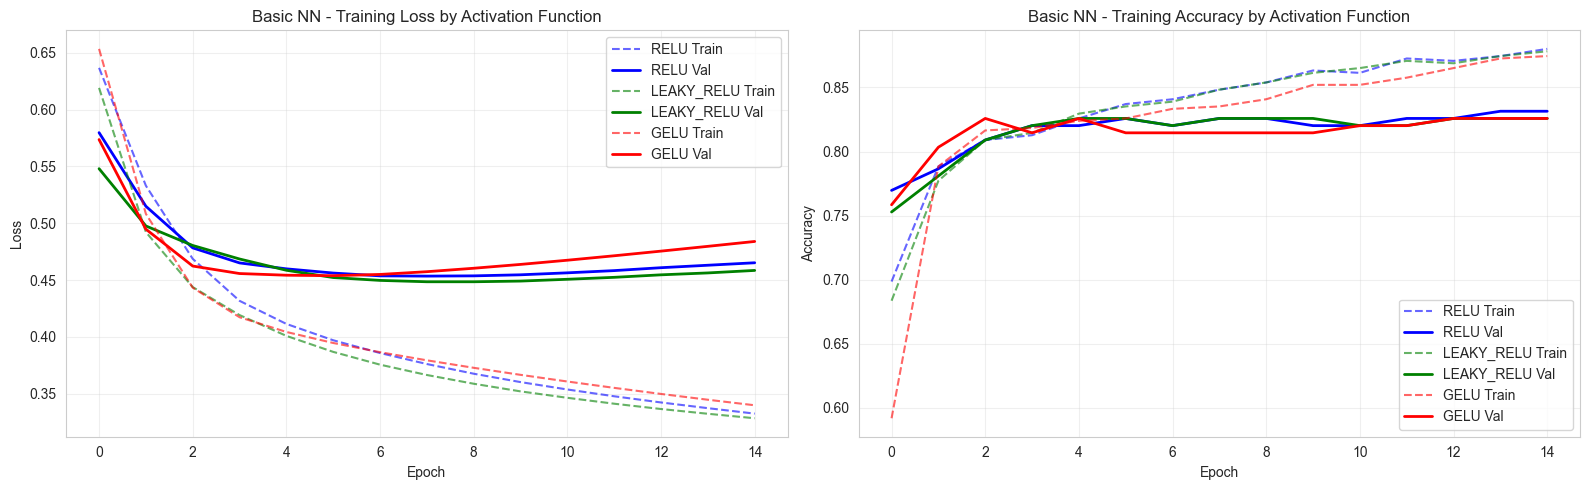

In [27]:
# Visualize Basic NN training histories
print("Basic NN - Training Curves Comparison")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = {'relu': 'blue', 'leaky_relu': 'green', 'gelu': 'red'}

# Loss plot
for activation in activations:
    history = basic_histories[activation]
    axes[0].plot(history.history['loss'], '--', color=colors[activation], alpha=0.6, 
                 label=f'{activation.upper()} Train')
    axes[0].plot(history.history['val_loss'], '-', color=colors[activation], linewidth=2,
                 label=f'{activation.upper()} Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Basic NN - Training Loss by Activation Function')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
for activation in activations:
    history = basic_histories[activation]
    axes[1].plot(history.history['accuracy'], '--', color=colors[activation], alpha=0.6,
                 label=f'{activation.upper()} Train')
    axes[1].plot(history.history['val_accuracy'], '-', color=colors[activation], linewidth=2,
                 label=f'{activation.upper()} Val')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Basic NN - Training Accuracy by Activation Function')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

BASIC NN - METRICS COMPARISON BY ACTIVATION FUNCTION
            Accuracy  Precision  Recall  F1 Score  ROC AUC
Activation                                                
RELU          0.7765     0.7377  0.6522    0.6923   0.8339
LEAKY_RELU    0.7877     0.7541  0.6667    0.7077   0.8319
GELU          0.8045     0.7742  0.6957    0.7328   0.8215


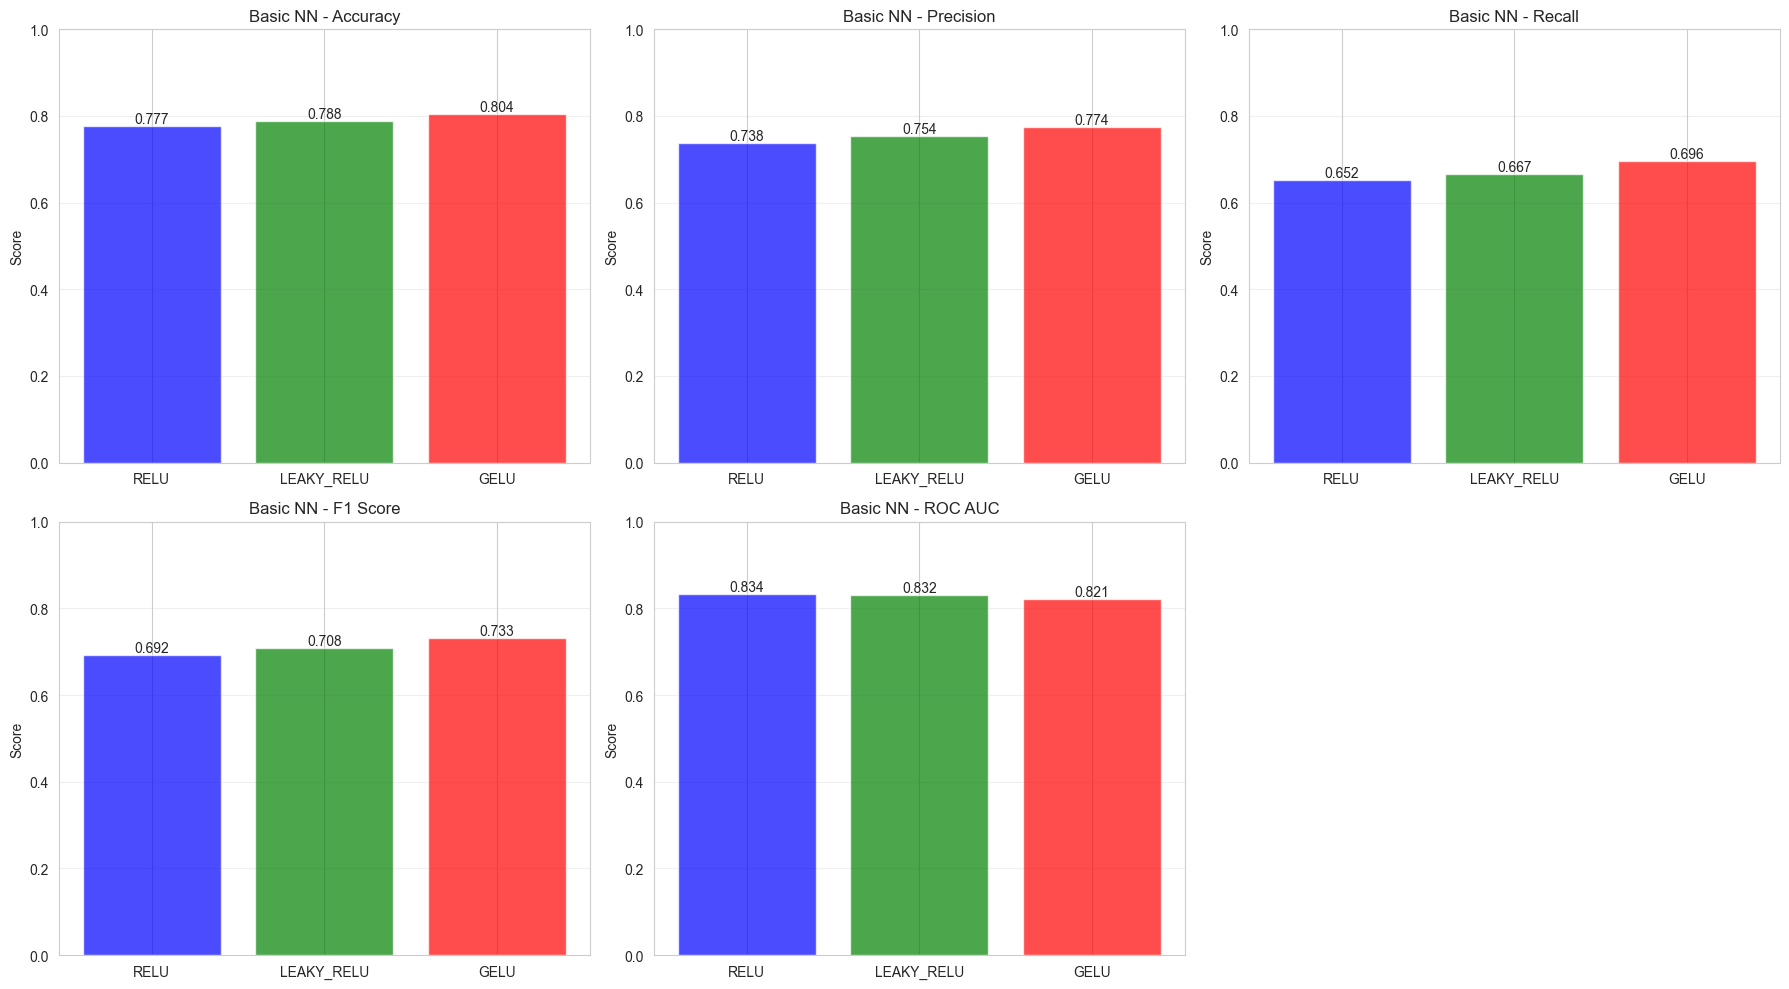

In [28]:
# Compare Basic NN metrics across activation functions
basic_comparison = pd.DataFrame([basic_results[act] for act in activations])
basic_comparison['Activation'] = [act.upper() for act in activations]
basic_comparison = basic_comparison.set_index('Activation').drop('Model', axis=1)

print("="*80)
print("BASIC NN - METRICS COMPARISON BY ACTIVATION FUNCTION")
print("="*80)
print(basic_comparison.round(4))

# Visualize metrics comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
colors_list = ['blue', 'green', 'red']

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    bars = ax.bar(range(len(activations)), basic_comparison[metric].values, 
                   color=colors_list, alpha=0.7)
    ax.set_xticks(range(len(activations)))
    ax.set_xticklabels([a.upper() for a in activations])
    ax.set_ylabel('Score')
    ax.set_title(f'Basic NN - {metric}')
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

### 4.2 Advanced Neural Network - Activation Function Comparison

Advanced network with Dropout (0.3), Batch Normalization, and L2 regularization (0.001)

In [29]:
print("="*80)
print("ADVANCED NEURAL NETWORK - ACTIVATION FUNCTION COMPARISON")
print("="*80)

# Fixed hyperparameters
DROPOUT_RATE = 0.3
L2_REG = 0.001

# Store results
advanced_models = {}
advanced_histories = {}
advanced_results = {}

for activation in activations:
    print(f"\n{'='*80}")
    print(f"Training Advanced NN with {activation.upper()} activation")
    print(f"{'='*80}")
    
    # Create model
    model = create_advanced_nn(
        input_dim=input_dim,
        hidden_size1=HIDDEN_SIZE1,
        hidden_size2=HIDDEN_SIZE2,
        dropout_rate=DROPOUT_RATE,
        activation=activation,
        learning_rate=LEARNING_RATE,
        l2_reg=L2_REG
    )
    
    # Print model info
    print(f"\nModel Architecture:")
    model.summary()
    print(f"\nActivation function: {activation}")
    print(f"Dropout rate: {DROPOUT_RATE}")
    print(f"L2 regularization: {L2_REG}")
    print(f"Training for {NUM_EPOCHS} epochs...")
    
    # Train model
    history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=NUM_EPOCHS,
        batch_size=32,
        verbose=1
    )
    
    # Store model and history
    advanced_models[activation] = model
    advanced_histories[activation] = history
    
    # Evaluate on test set
    results, y_pred, y_pred_proba = evaluate_model(
        model, X_test_scaled, y_test, f'Advanced NN ({activation.upper()})'
    )
    advanced_results[activation] = results
    
    print(f"\nTest Set Results for Advanced NN ({activation.upper()}):")
    for key, value in results.items():
        if key != 'Model':
            print(f"{key}: {value:.4f}")

print(f"\n{'='*80}")
print("ADVANCED NN TRAINING COMPLETED FOR ALL ACTIVATIONS")
print(f"{'='*80}")

ADVANCED NEURAL NETWORK - ACTIVATION FUNCTION COMPARISON

Training Advanced NN with RELU activation

Model Architecture:


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 64)             │         1,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,353 (17.00 KB)

 Trainable params: 4,161 (16.25 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                │ (None, 64)             │         1,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,353 (17.00 KB)

 Trainable params: 4,161 (16.25 KB)

 Non-trainable params: 192 (768.00 B)


Activation function: gelu
Dropout rate: 0.3
L2 regularization: 0.001
Training for 15 epochs...
Epoch 1/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6466 - loss: 0.8242 - val_accuracy: 0.7022 - val_loss: 0.7324
Epoch 2/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7213 - loss: 0.6566 - val_accuracy: 0.7584 - val_loss: 0.6523
Epoch 3/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7740 - loss: 0.6168 - val_accuracy: 0.7640 - val_loss: 0.6068
Epoch 4/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7815 - loss: 0.5772 - val_accuracy: 0.7921 - val_loss: 0.5754
Epoch 5/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8167 - loss: 0.5346 - val_accuracy: 0.8146 - val_loss: 0.5554
Epoch 6/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8313 - loss: 0.5243 - val_accuracy: 0.8202 - val_loss: 0.5438
Epoch 7/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8232 - loss: 0.5246 - val_accuracy: 0.8258 - val_loss: 0.5364
Epoch 8/15
17/17 ━━━━

Advanced NN - Training Curves Comparison


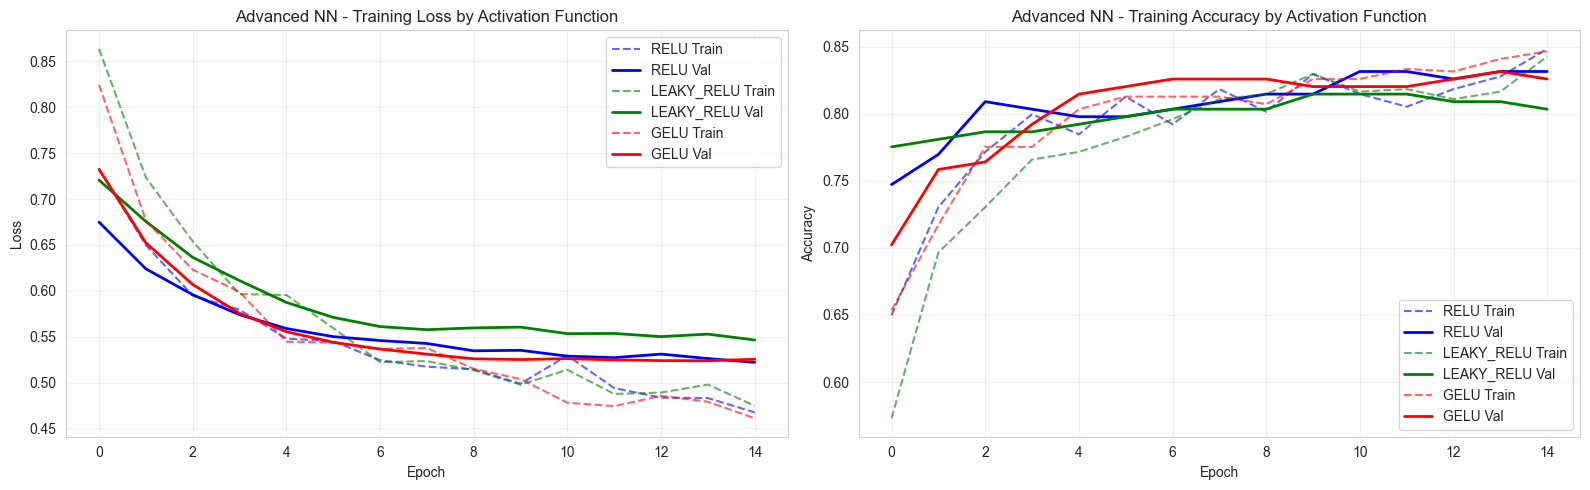

In [30]:
# Visualize Advanced NN training histories
print("Advanced NN - Training Curves Comparison")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss plot
for activation in activations:
    history = advanced_histories[activation]
    axes[0].plot(history.history['loss'], '--', color=colors[activation], alpha=0.6, 
                 label=f'{activation.upper()} Train')
    axes[0].plot(history.history['val_loss'], '-', color=colors[activation], linewidth=2,
                 label=f'{activation.upper()} Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Advanced NN - Training Loss by Activation Function')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
for activation in activations:
    history = advanced_histories[activation]
    axes[1].plot(history.history['accuracy'], '--', color=colors[activation], alpha=0.6,
                 label=f'{activation.upper()} Train')
    axes[1].plot(history.history['val_accuracy'], '-', color=colors[activation], linewidth=2,
                 label=f'{activation.upper()} Val')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Advanced NN - Training Accuracy by Activation Function')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

ADVANCED NN - METRICS COMPARISON BY ACTIVATION FUNCTION
            Accuracy  Precision  Recall  F1 Score  ROC AUC
Activation                                                
RELU          0.8045     0.7742  0.6957    0.7328   0.8350
LEAKY_RELU    0.7877     0.7246  0.7246    0.7246   0.8204
GELU          0.8101     0.7536  0.7536    0.7536   0.8208


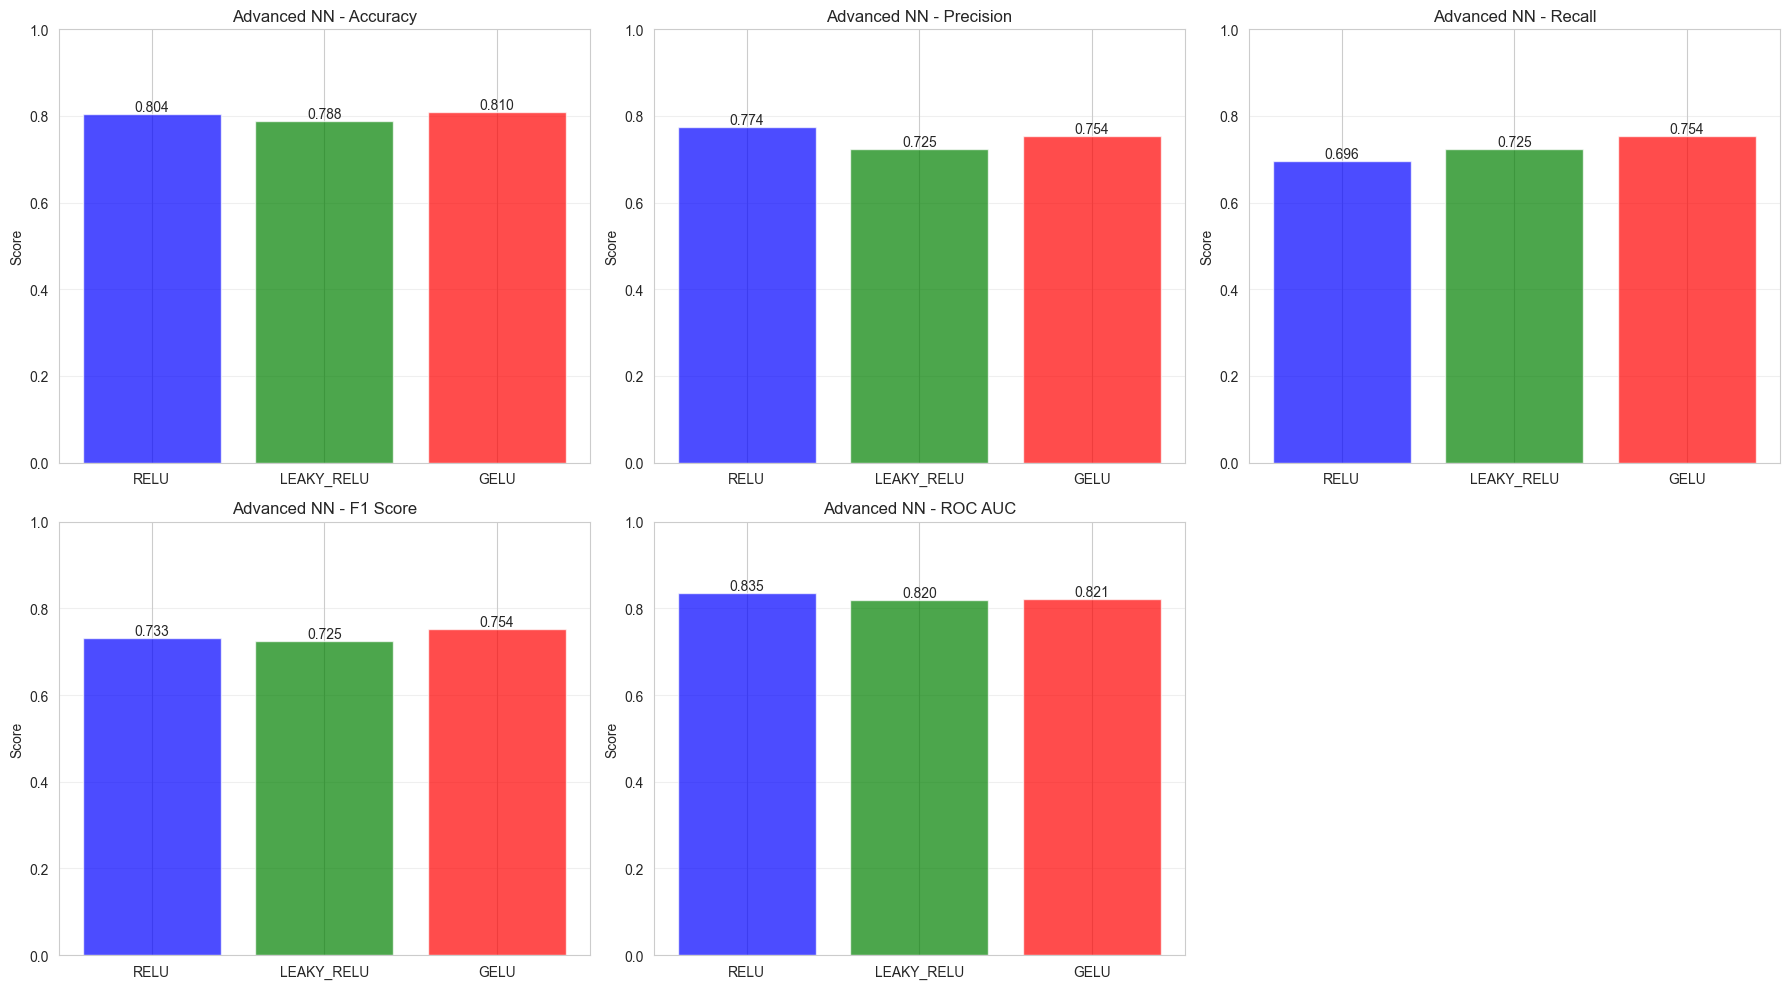

In [31]:
# Compare Advanced NN metrics across activation functions
advanced_comparison = pd.DataFrame([advanced_results[act] for act in activations])
advanced_comparison['Activation'] = [act.upper() for act in activations]
advanced_comparison = advanced_comparison.set_index('Activation').drop('Model', axis=1)

print("="*80)
print("ADVANCED NN - METRICS COMPARISON BY ACTIVATION FUNCTION")
print("="*80)
print(advanced_comparison.round(4))

# Visualize metrics comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    bars = ax.bar(range(len(activations)), advanced_comparison[metric].values, 
                   color=colors_list, alpha=0.7)
    ax.set_xticks(range(len(activations)))
    ax.set_xticklabels([a.upper() for a in activations])
    ax.set_ylabel('Score')
    ax.set_title(f'Advanced NN - {metric}')
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

## 5. Overall Comparison: Basic vs Advanced Networks

In [35]:
# Create comprehensive comparison table
all_results = []

for activation in activations:
    basic_res = basic_results[activation].copy()
    basic_res['Architecture'] = 'Basic NN'
    basic_res['Activation'] = activation.upper()
    all_results.append(basic_res)
    
    adv_res = advanced_results[activation].copy()
    adv_res['Architecture'] = 'Advanced NN'
    adv_res['Activation'] = activation.upper()
    all_results.append(adv_res)

comparison_df = pd.DataFrame(all_results)
comparison_df = comparison_df[['Architecture', 'Activation', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']]

print("="*80)
print("COMPLETE COMPARISON: ALL MODELS AND ACTIVATIONS")
print("="*80)
print(comparison_df.round(4).to_string(index=False))

# Find best models
print("\n" + "="*80)
print("BEST MODELS BY METRIC")
print("="*80)
for metric in ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']:
    best_idx = comparison_df[metric].idxmax()
    best_row = comparison_df.loc[best_idx]
    print(f"{metric:12s}: {best_row['Architecture']:12s} with {best_row['Activation']:10s} = {best_row[metric]:.4f}")

COMPLETE COMPARISON: ALL MODELS AND ACTIVATIONS
Architecture Activation  Accuracy  Precision  Recall  F1 Score  ROC AUC
    Basic NN       RELU    0.7765     0.7377  0.6522    0.6923   0.8339
 Advanced NN       RELU    0.8045     0.7742  0.6957    0.7328   0.8350
    Basic NN LEAKY_RELU    0.7877     0.7541  0.6667    0.7077   0.8319
 Advanced NN LEAKY_RELU    0.7877     0.7246  0.7246    0.7246   0.8204
    Basic NN       GELU    0.8045     0.7742  0.6957    0.7328   0.8215
 Advanced NN       GELU    0.8101     0.7536  0.7536    0.7536   0.8208

BEST MODELS BY METRIC
Accuracy    : Advanced NN  with GELU       = 0.8101
Precision   : Advanced NN  with RELU       = 0.7742
Recall      : Advanced NN  with GELU       = 0.7536
F1 Score    : Advanced NN  with GELU       = 0.7536
ROC AUC     : Advanced NN  with RELU       = 0.8350


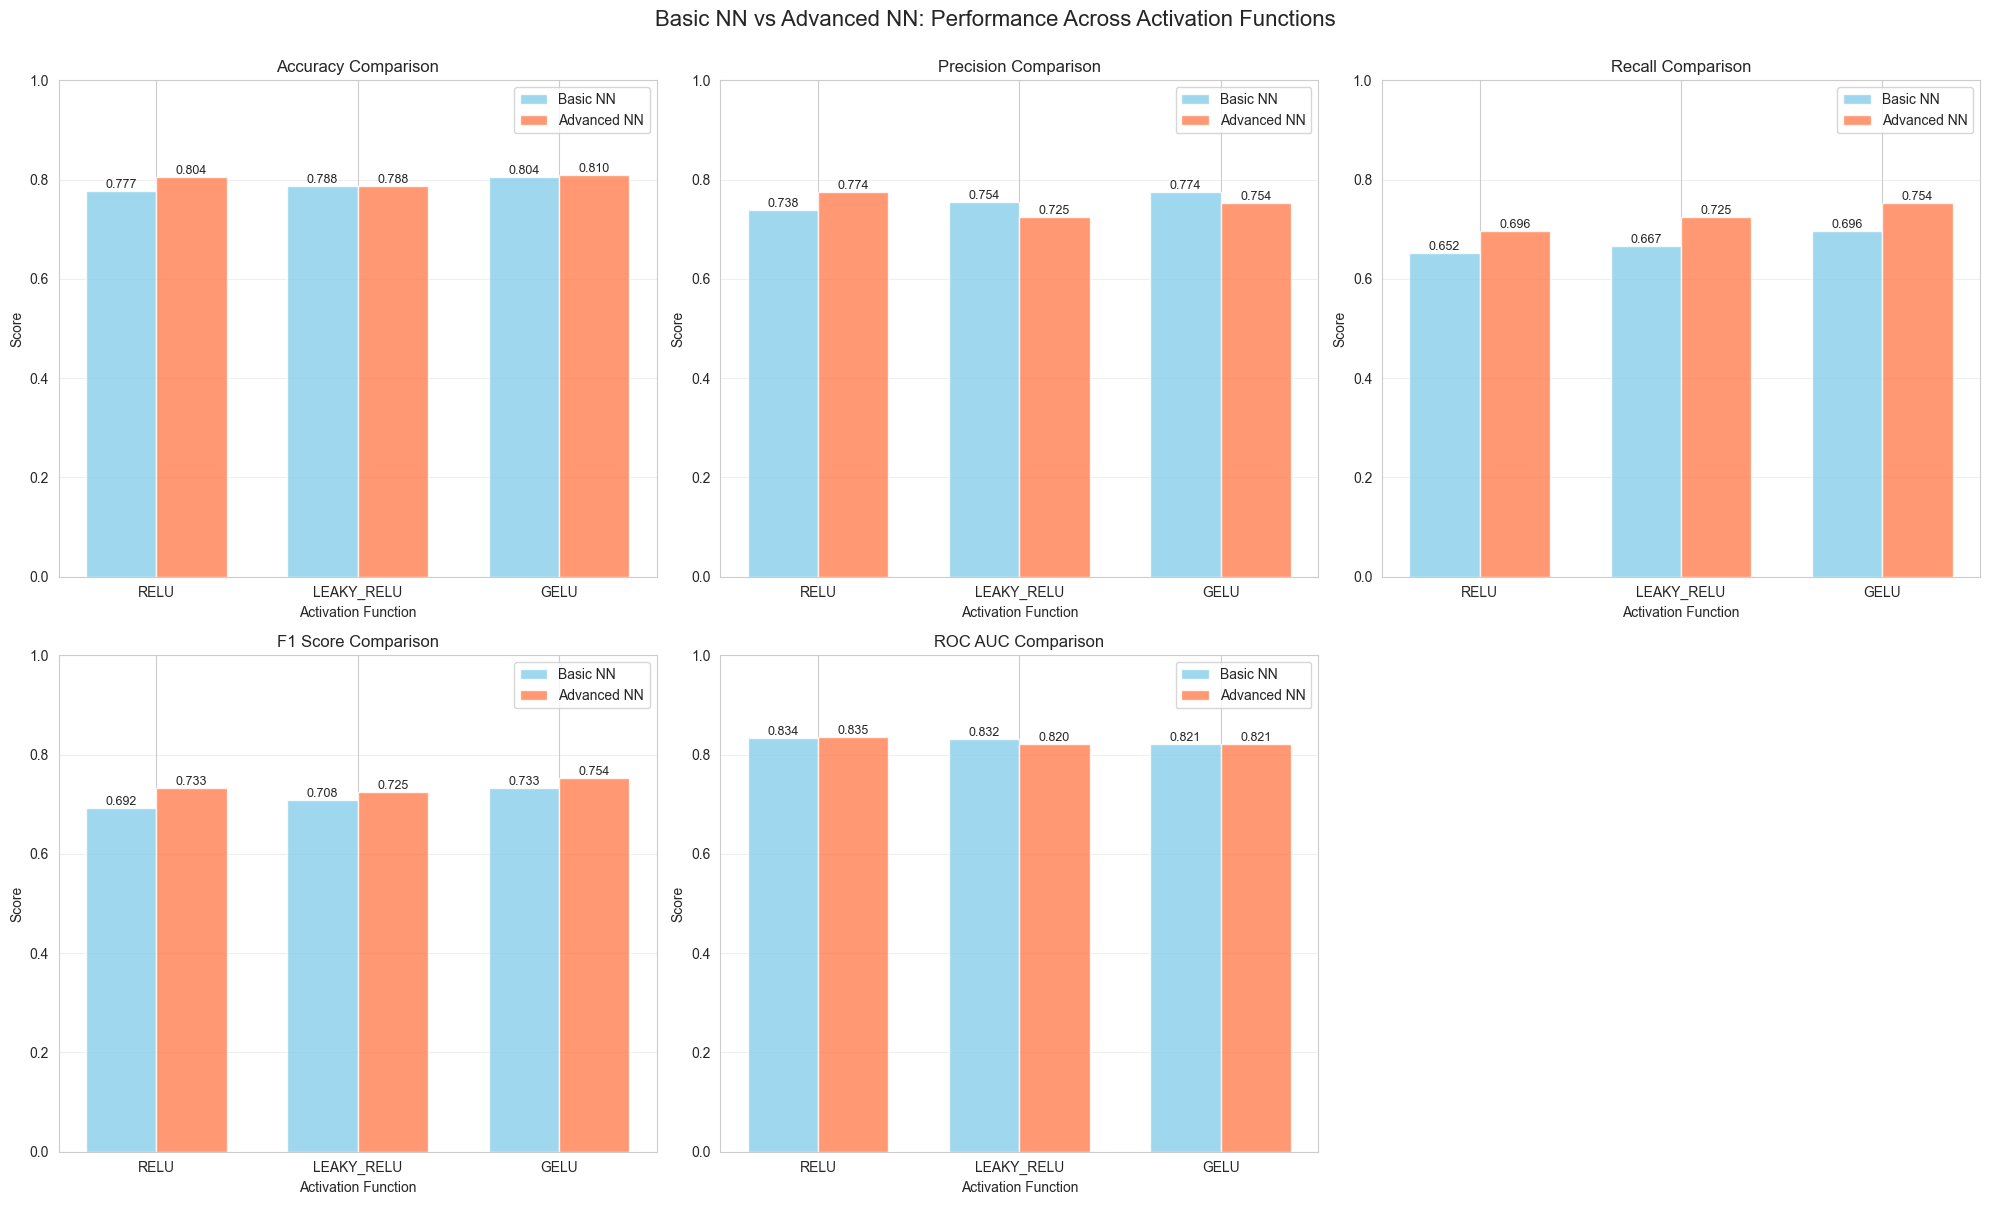

In [36]:
# Visualize overall comparison
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

# Prepare data for grouped bar charts
x = np.arange(len(activations))
width = 0.35

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    basic_values = [basic_results[act][metric] for act in activations]
    advanced_values = [advanced_results[act][metric] for act in activations]
    
    bars1 = ax.bar(x - width/2, basic_values, width, label='Basic NN', alpha=0.8, color='skyblue')
    bars2 = ax.bar(x + width/2, advanced_values, width, label='Advanced NN', alpha=0.8, color='coral')
    
    ax.set_xlabel('Activation Function')
    ax.set_ylabel('Score')
    ax.set_title(f'{metric} Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels([a.upper() for a in activations])
    ax.legend()
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9)

fig.delaxes(axes[5])
plt.suptitle('Basic NN vs Advanced NN: Performance Across Activation Functions', 
             fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

## 6. Summary and Conclusions

In [37]:
# Summary of key findings
print("="*80)
print("EXPERIMENT SUMMARY (TensorFlow/Keras)")
print("="*80)
print(f"\nDataset: Titanic Survival Classification")
print(f"Class Distribution: Imbalanced (61.6% not survived, 38.4% survived)")
print(f"\nArchitectures Tested:")
print(f"  1. Basic NN: 2 hidden layers (64, 32 neurons)")
print(f"  2. Advanced NN: 2 hidden layers with Dropout, BatchNorm, L2 regularization")
print(f"\nActivation Functions Compared: ReLU, LeakyReLU, GELU")
print(f"Training Configuration:")
print(f"  - Epochs: {NUM_EPOCHS}")
print(f"  - Optimizer: Adam")
print(f"  - Learning Rate: {LEARNING_RATE}")
print(f"  - L2 Regularization (Advanced): {L2_REG}")
print(f"  - Dropout Rate (Advanced): {DROPOUT_RATE}")

print("\n" + "="*80)
print("KEY OBSERVATIONS")
print("="*80)

# Compare Basic vs Advanced overall
basic_avg = basic_comparison.mean()
advanced_avg = advanced_comparison.mean()

print("\nAverage Performance Across Activations:")
print("-" * 50)
print(f"{'Metric':<15} {'Basic NN':<12} {'Advanced NN':<12} {'Difference':<12}")
print("-" * 50)
for metric in ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']:
    diff = advanced_avg[metric] - basic_avg[metric]
    print(f"{metric:<15} {basic_avg[metric]:>10.4f}  {advanced_avg[metric]:>10.4f}  {diff:>+10.4f}")

print("\n" + "="*80)
print("ACTIVATION FUNCTION INSIGHTS")
print("="*80)

for architecture, results_dict in [('Basic NN', basic_results), ('Advanced NN', advanced_results)]:
    print(f"\n{architecture}:")
    print("-" * 50)
    best_act = max(activations, key=lambda x: results_dict[x]['F1 Score'])
    worst_act = min(activations, key=lambda x: results_dict[x]['F1 Score'])
    print(f"  Best activation (by F1):  {best_act.upper()} = {results_dict[best_act]['F1 Score']:.4f}")
    print(f"  Worst activation (by F1): {worst_act.upper()} = {results_dict[worst_act]['F1 Score']:.4f}")

EXPERIMENT SUMMARY (TensorFlow/Keras)

Dataset: Titanic Survival Classification
Class Distribution: Imbalanced (61.6% not survived, 38.4% survived)

Architectures Tested:
  1. Basic NN: 2 hidden layers (64, 32 neurons)
  2. Advanced NN: 2 hidden layers with Dropout, BatchNorm, L2 regularization

Activation Functions Compared: ReLU, LeakyReLU, GELU
Training Configuration:
  - Epochs: 15
  - Optimizer: Adam
  - Learning Rate: 0.001
  - L2 Regularization (Advanced): 0.001
  - Dropout Rate (Advanced): 0.3

KEY OBSERVATIONS

Average Performance Across Activations:
--------------------------------------------------
Metric          Basic NN     Advanced NN  Difference  
--------------------------------------------------
Accuracy            0.7896      0.8007     +0.0112
Precision           0.7553      0.7508     -0.0045
Recall              0.6715      0.7246     +0.0531
F1 Score            0.7109      0.7370     +0.0261
ROC AUC             0.8291      0.8254     -0.0036

ACTIVATION FUNCTION I

## 7. Save TensorFlow Models

In [38]:
# Create models directory
models_dir = Path('../models/tensorflow')
models_dir.mkdir(parents=True, exist_ok=True)

# Save all models
print("="*80)
print("SAVING MODELS")
print("="*80)

saved_models = []

for activation in activations:
    # Save Basic NN
    basic_path = models_dir / f'basic_nn_{activation}.keras'
    basic_models[activation].save(basic_path)
    saved_models.append(str(basic_path))
    print(f"✓ Saved: {basic_path.name}")
    
    # Save Advanced NN
    advanced_path = models_dir / f'advanced_nn_{activation}.keras'
    advanced_models[activation].save(advanced_path)
    saved_models.append(str(advanced_path))
    print(f"✓ Saved: {advanced_path.name}")

# Save scaler
scaler_path = models_dir / 'scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
saved_models.append(str(scaler_path))
print(f"✓ Saved: {scaler_path.name}")

# Save comparison results
comparison_path = models_dir / 'activation_comparison_results.csv'
comparison_df.to_csv(comparison_path, index=False)
saved_models.append(str(comparison_path))
print(f"✓ Saved: {comparison_path.name}")

# Save training histories as JSON
import json

for activation in activations:
    # Save basic history
    basic_hist_path = models_dir / f'basic_nn_{activation}_history.json'
    with open(basic_hist_path, 'w') as f:
        json.dump({
            'loss': [float(x) for x in basic_histories[activation].history['loss']],
            'accuracy': [float(x) for x in basic_histories[activation].history['accuracy']],
            'val_loss': [float(x) for x in basic_histories[activation].history['val_loss']],
            'val_accuracy': [float(x) for x in basic_histories[activation].history['val_accuracy']]
        }, f)
    saved_models.append(str(basic_hist_path))
    
    # Save advanced history
    adv_hist_path = models_dir / f'advanced_nn_{activation}_history.json'
    with open(adv_hist_path, 'w') as f:
        json.dump({
            'loss': [float(x) for x in advanced_histories[activation].history['loss']],
            'accuracy': [float(x) for x in advanced_histories[activation].history['accuracy']],
            'val_loss': [float(x) for x in advanced_histories[activation].history['val_loss']],
            'val_accuracy': [float(x) for x in advanced_histories[activation].history['val_accuracy']]
        }, f)
    saved_models.append(str(adv_hist_path))

print(f"\nTotal files saved: {len(saved_models)}")
print(f"Location: {models_dir.absolute()}")

SAVING MODELS
✓ Saved: basic_nn_relu.keras
✓ Saved: advanced_nn_relu.keras
✓ Saved: basic_nn_leaky_relu.keras
✓ Saved: advanced_nn_leaky_relu.keras
✓ Saved: basic_nn_gelu.keras
✓ Saved: advanced_nn_gelu.keras
✓ Saved: scaler.pkl
✓ Saved: activation_comparison_results.csv

Total files saved: 14
Location: c:\Users\alexp\Documents\Programach\Python\titanic-classification-labs\notebooks\..\models\tensorflow
